# Intra vs extra donut blur across the Danish 1.3 blitz FAM ensemble (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-10-03  
**Last Modified:** 2026-10-04  
**Status:** In Progress  
**Keywords:** FAM, donut blur, Danish 1.3, blitz, unpaired, intra-focal, extra-focal, seeing, thermal telemetry  

## Description

Median donut blur per side of focus against FAM ordinal number, for the whole Danish 1.3
blitz unpaired FAM ensemble, and a test of what kind of offset separates the two sides.

Key functionality:
1. Read the per-side blur medians `median_blur_intra_arcsec` and
   `median_blur_extra_arcsec` from the blitz recast `visits.parquet`.
2. Plot both sides against FAM ordinal number, with a different marker and colour per
   side.
3. Fit three one-parameter models of the intra/extra relation — constant, fractional and
   quadrature — and compare them on robust residual scatter.
4. Test whether the **arithmetic difference** `intra - extra` of the two sides, with
   nothing subtracted, tracks thermal telemetry: the air temperature differences between
   the truss, M2, M1M3, camera and outside air, the camera body temperature, the M1M3
   glass-minus-air difference, and the M1M3 bulk thermal gradients and
   quadratic-in-radius term. Each quantity is ranked by Spearman rho on its own, then
   added to a joint Huber fit one at a time.
5. Check whether the telemetry differs between the intra-focal and extra-focal exposure,
   now that `visits.parquet` carries both exposure identifiers.
6. Test whether removing the thermal model tightens the relation between the intra/extra
   difference and the extra-focal blur itself.

The ensemble matters because seeing drifts between the intra-focal and extra-focal
exposures of a single FAM triplet. One triplet cannot separate a real side-of-focus bias
from that drift; 966 triplets can, because the drift averages out while a systematic
offset does not.

**Output:** plots under `output/fam_processing/blur_intra_extra/`, plus a cached
`thermal_join_per_side_cam.parquet` of the per-exposure thermal telemetry in the same
directory.

**Based on:** `aos/docs/studies/fam_processing.md`, the `blitz_reader` recast of the
Danish 1.3 unpaired FAM product into the Danish 1.2 schema. The per-side columns this
notebook reads were added to `blitz_reader.donut_table` and `blitz_reader.visit_metrics`
on 2026-10-03; before that the recast kept only the two-side mean.


## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-10-03 | Aaron Roodman | Initial version |
| 2026-10-03 | Aaron Roodman | `day_obs` annotations and per-night medians on the ordinal plot; thermal telemetry section |
| 2026-10-04 | Aaron Roodman | Thermal section simplified to visit-by-visit on the signed quadrature difference, ranked and built up one variable at a time; M1M3 glass temperature and per-side exposure identifiers added |
| 2026-10-06 | Aaron Roodman | Thermal section switched to the arithmetic difference `intra - extra`; camera body temperature added; residual tested against extra-focal blur |


## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Blur vs FAM ordinal](#ordinal)
6. [What kind of offset?](#offset)
7. [Thermal dependence](#thermal)
8. [Residual against extra-focal blur](#resid-extra)
9. [Summary](#summary)


<a id='params'></a>
## Parameters


In [1]:
# ============================================================
# Parameters
# ============================================================

PARAM_SET = 'danish_1_3_test'   # blitz recast of the Danish 1.3 unpaired FAM product
QUALITY_ONLY = True             # keep only visits with visit_quality_pass True
SAVE_PLOTS = True               # write PDFs under output/fam_processing/blur_intra_extra/

# A night mean estimated from one or two triplets would manufacture a within-night
# correlation, so nights below this count are dropped from the within-night columns only.
MIN_NIGHT_TRIPLETS = 5          # dimensionless

# Marker and colour per side of focus, used in every plot below.
SIDE_STYLE = {
    'intra': {'color': '#1f77b4', 'marker': 'o', 'label': 'intra-focal'},
    'extra': {'color': '#d62728', 'marker': '^', 'label': 'extra-focal'},
}


<a id='setup'></a>
## Setup & Imports


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))      # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import nmad, setup_plotting

setup_plotting()

OUT_DIR = _TOPIC / 'output' / 'fam_processing' / 'blur_intra_extra'
if SAVE_PLOTS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'topic: {_TOPIC}')
print(f'output: {OUT_DIR}')


topic: /sdf/home/r/roodman/notebooks/rubin-work/aos
output: /sdf/home/r/roodman/notebooks/rubin-work/aos/output/fam_processing/blur_intra_extra


<a id='functions'></a>
## Helper Functions


In [3]:
def fit_offset_models(b_intra, b_extra):
    """Fit the three one-parameter models of the intra/extra blur relation.

    Each model has a single free parameter, so their residual scatters are directly
    comparable. Every parameter is estimated with a median rather than a mean, so a
    handful of bad visits cannot drive the comparison.

    Parameters
    ----------
    b_intra, b_extra : `numpy.ndarray`
        Per-visit median donut blur on each side of focus, in arcsec. Same length;
        non-finite entries are dropped pairwise.

    Returns
    -------
    models : `dict`
        One entry per model name (``'constant'``, ``'fractional'``, ``'quadrature'``),
        each a `dict` with ``param`` (the fitted parameter, units in ``param_units``),
        ``param_units``, ``predicted`` (predicted intra blur, arcsec), ``residual``
        (observed minus predicted intra blur, arcsec), ``nmad_arcsec`` (robust residual
        scatter, arcsec) and ``median_abs_arcsec`` (median absolute residual, arcsec).
        The extra key ``n`` is the number of triplets fitted, dimensionless.

    Notes
    -----
    The quadrature parameter is the median of ``b_intra**2 - b_extra**2`` in arcsec**2,
    which is signed: it is negative for an ensemble where intra is the sharper side. The
    predicted blur uses ``sqrt(max(b_extra**2 + q, 0))``.
    """
    b_intra = np.asarray(b_intra, dtype=float)
    b_extra = np.asarray(b_extra, dtype=float)
    ok = np.isfinite(b_intra) & np.isfinite(b_extra)
    bi, be = b_intra[ok], b_extra[ok]

    c = float(np.median(bi - be))
    f = float(np.median(bi / be))
    q = float(np.median(bi**2 - be**2))

    models = {
        'constant': {'param': c, 'param_units': 'arcsec',
                     'predicted': be + c},
        'fractional': {'param': f, 'param_units': 'dimensionless (intra/extra)',
                       'predicted': f * be},
        'quadrature': {'param': q, 'param_units': 'arcsec**2',
                       'predicted': np.sqrt(np.clip(be**2 + q, 0.0, None))},
    }
    for m in models.values():
        m['residual'] = bi - m['predicted']
        m['nmad_arcsec'] = float(nmad(m['residual']))
        m['median_abs_arcsec'] = float(np.median(np.abs(m['residual'])))
    models['n'] = int(ok.sum())
    return models


<a id='data'></a>
## Data Access

`visits.parquet` from the blitz recast carries one row per FAM triplet. The per-side
columns `median_blur_intra_arcsec` and `median_blur_extra_arcsec` are the median over
that side's donuts of the blitz `group_fwhm`, in arcsec; `median_blur_arcsec` is the
median of the two-side mean and is the column the quality cut uses.

The **FAM ordinal number** is the position of the triplet in time order across the whole
ensemble, so it indexes the triplet rather than the exposure.


In [4]:
visits_file = _TOPIC / 'output' / 'fam_processing' / PARAM_SET / 'visits.parquet'
v = pd.read_parquet(visits_file)

needed = ['median_blur_intra_arcsec', 'median_blur_extra_arcsec']
missing = [c for c in needed if c not in v.columns]
if missing:
    raise KeyError(
        f'{visits_file} lacks {missing}; rebuild it with '
        f'`python code/fam_processing/run_blitz_mktable.py --param-set {PARAM_SET} '
        f'--overwrite`, which writes the per-side blur medians')

v = v.sort_values(['day_obs', 'seq_num']).reset_index(drop=True)
print(f'{len(v)} FAM triplets, nights {v["day_obs"].min()} to {v["day_obs"].max()}, '
      f'{v["day_obs"].nunique()} nights')

if QUALITY_ONLY and 'visit_quality_pass' in v.columns:
    n_before = len(v)
    v = v[v['visit_quality_pass'].astype(bool)].reset_index(drop=True)
    print(f'quality cut (visit_quality_pass): kept {len(v)} of {n_before} triplets')

v['fam_ordinal'] = np.arange(1, len(v) + 1)

b_intra = v['median_blur_intra_arcsec'].to_numpy(float)
b_extra = v['median_blur_extra_arcsec'].to_numpy(float)
finite = np.isfinite(b_intra) & np.isfinite(b_extra)
print(f'both sides finite: {int(finite.sum())} of {len(v)} triplets')
print(f'median intra-focal blur = {np.nanmedian(b_intra):.4f} arcsec')
print(f'median extra-focal blur = {np.nanmedian(b_extra):.4f} arcsec')


966 FAM triplets, nights 20260315 to 20260619, 15 nights
quality cut (visit_quality_pass): kept 873 of 966 triplets
both sides finite: 873 of 873 triplets
median intra-focal blur = 1.0526 arcsec
median extra-focal blur = 0.6636 arcsec


<a id='ordinal'></a>
## Blur vs FAM ordinal

Both sides on one axis, intra-focal in blue circles and extra-focal in red triangles.
Grey vertical lines separate the nights and each block carries its `day_obs`, because the
difference between the two sides is far more a night-level quantity than a within-night
one: the lower panel's per-night medians run from roughly 0.1 to 0.5 arcsec while the
scatter inside a night is smaller than that spread.

That night-to-night structure is what motivates the thermal section below.


/lscratch/roodman/ipykernel_3593907/4200600601.py:55: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


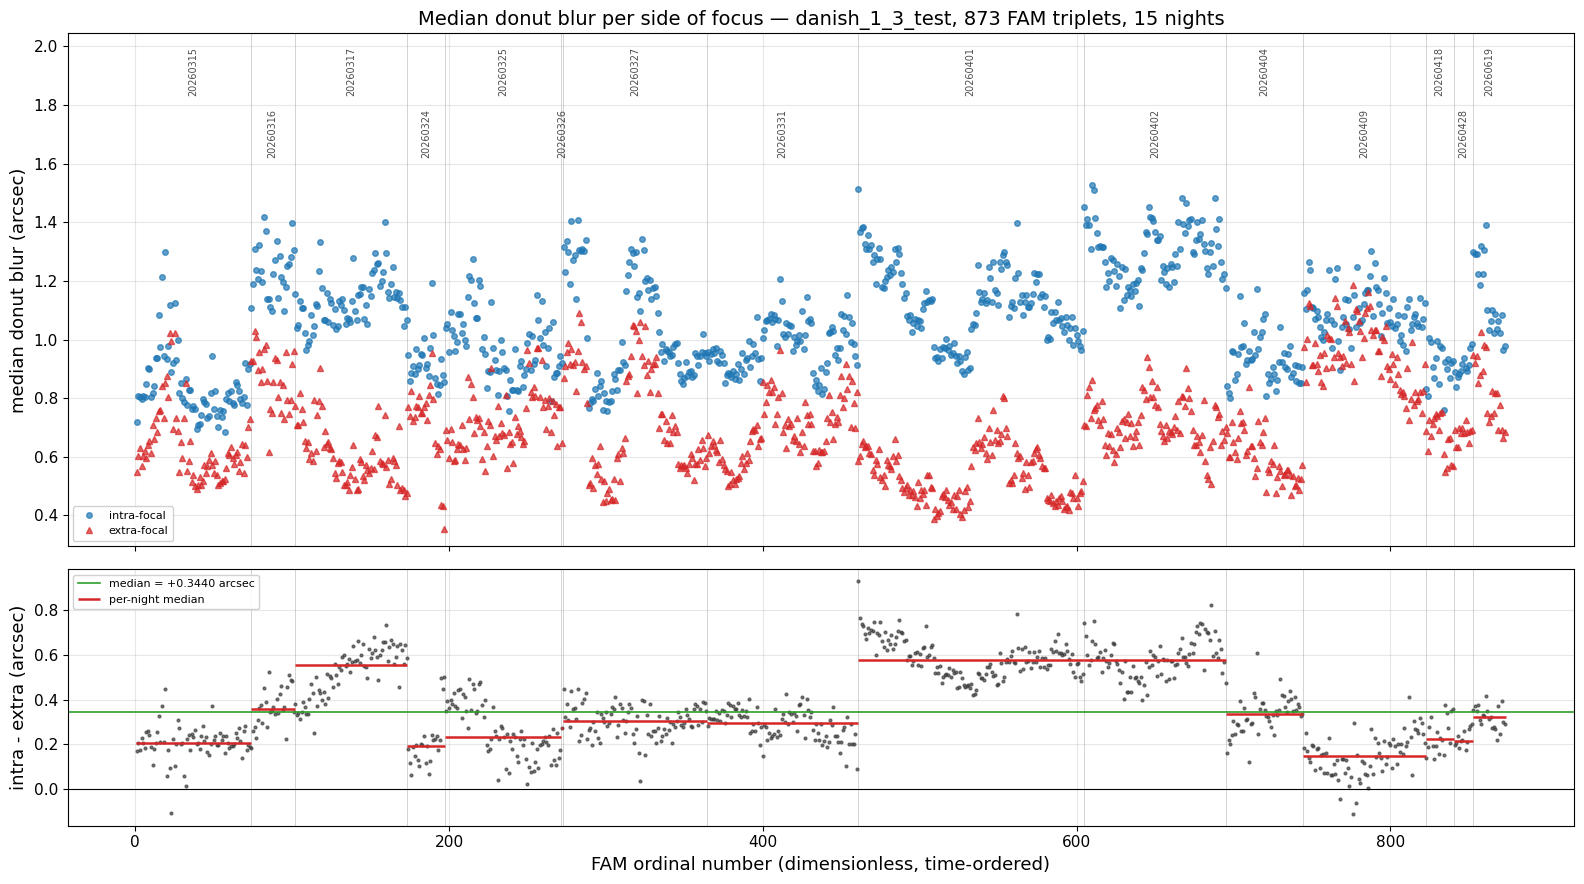

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                        gridspec_kw={'height_ratios': [2, 1]})

ax = axs[0]
for key, values in (('intra', b_intra), ('extra', b_extra)):
    s = SIDE_STYLE[key]
    ax.plot(v['fam_ordinal'], values, linestyle='none', marker=s['marker'],
            color=s['color'], markersize=4, alpha=0.7, label=s['label'])

# Night boundaries, plus the day_obs of each night written above its block of triplets.
# Which night a block belongs to is the whole point of the figure: the intra/extra
# difference changes from night to night by much more than it varies within one night.
day_obs_arr = v['day_obs'].to_numpy()
night_edges = np.flatnonzero(np.diff(day_obs_arr) != 0) + 1
block_starts = np.concatenate(([0], night_edges))
block_ends = np.concatenate((night_edges, [len(v)]))

ymax = float(np.nanmax([np.nanmax(b_intra), np.nanmax(b_extra)]))
ax.set_ylim(top=ymax * 1.34)
# Alternating heights so a short night's label does not collide with its neighbour, and
# the labels sit above the legend rather than behind it.
for j, (i0, i1) in enumerate(zip(block_starts, block_ends)):
    ax.text(0.5 * (i0 + i1) + 0.5, ymax * (1.31 if j % 2 == 0 else 1.17),
            str(int(day_obs_arr[i0])), rotation=90, ha='center', va='top',
            fontsize=7, color='0.3')

for ax_ in axs:
    for e in night_edges:
        ax_.axvline(e + 0.5, color='0.8', linewidth=0.6, zorder=0)

ax.set_ylabel('median donut blur (arcsec)')
ax.set_title(f'Median donut blur per side of focus — {PARAM_SET}, '
             f'{len(v)} FAM triplets, {v["day_obs"].nunique()} nights')
ax.legend(loc='lower left', framealpha=0.9, fontsize=8)

ax = axs[1]
diff = b_intra - b_extra
ax.plot(v['fam_ordinal'], diff, linestyle='none', marker='.', color='0.25',
        markersize=4, alpha=0.7)
ax.axhline(0.0, color='k', linewidth=0.8)
ax.axhline(float(np.nanmedian(diff)), color='#2ca02c', linewidth=1.2,
           label=f'median = {np.nanmedian(diff):+.4f} arcsec')

# Per-night median of the difference, to show it is a night-level quantity.
for i0, i1 in zip(block_starts, block_ends):
    med_night = float(np.nanmedian(diff[i0:i1]))
    ax.plot([i0 + 0.5, i1 + 0.5], [med_night, med_night], color='#d62728',
            linewidth=1.8, solid_capstyle='butt',
            label='per-night median' if i0 == 0 else None)

ax.set_xlabel('FAM ordinal number (dimensionless, time-ordered)')
ax.set_ylabel('intra - extra (arcsec)')
ax.legend(loc='upper left', framealpha=0.9, fontsize=8)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_vs_fam_ordinal.pdf')
plt.show()


<a id='offset'></a>
## What kind of offset?

Three one-parameter models, each fitted by a median so outlying triplets cannot drive the
comparison:

| model | relation | parameter |
|---|---|---|
| constant | `b_intra = b_extra + c` | `c` in arcsec |
| fractional | `b_intra = f * b_extra` | `f` dimensionless |
| quadrature | `b_intra**2 = b_extra**2 + q` | `q` in arcsec**2 |

The discriminator is how the intra/extra difference trends with the blur itself. A
constant offset means the difference is flat against extra blur; a fractional offset
means it grows linearly; a quadrature offset means it *falls* as blur grows, because
adding in quadrature matters less when the base is already large.


In [6]:
models = fit_offset_models(b_intra, b_extra)
n_fit = models['n']

print(f'n = {n_fit} FAM triplets with both sides finite\n')
summary = pd.DataFrame([
    {'model': name,
     'parameter': f"{models[name]['param']:+.5f}",
     'units': models[name]['param_units'],
     'resid nMAD (arcsec)': f"{models[name]['nmad_arcsec']:.5f}",
     'median |resid| (arcsec)': f"{models[name]['median_abs_arcsec']:.5f}"}
    for name in ('constant', 'fractional', 'quadrature')])
print(summary.to_string(index=False))

best = min(('constant', 'fractional', 'quadrature'),
           key=lambda k: models[k]['nmad_arcsec'])
print(f'\nlowest robust residual scatter: {best}')


n = 873 FAM triplets with both sides finite

     model parameter                       units resid nMAD (arcsec) median |resid| (arcsec)
  constant  +0.34395                      arcsec             0.20379                 0.13745
fractional  +1.49989 dimensionless (intra/extra)             0.23984                 0.16177
quadrature  +0.56140                   arcsec**2             0.17863                 0.12049

lowest robust residual scatter: quadrature


/lscratch/roodman/ipykernel_3593907/2163611049.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


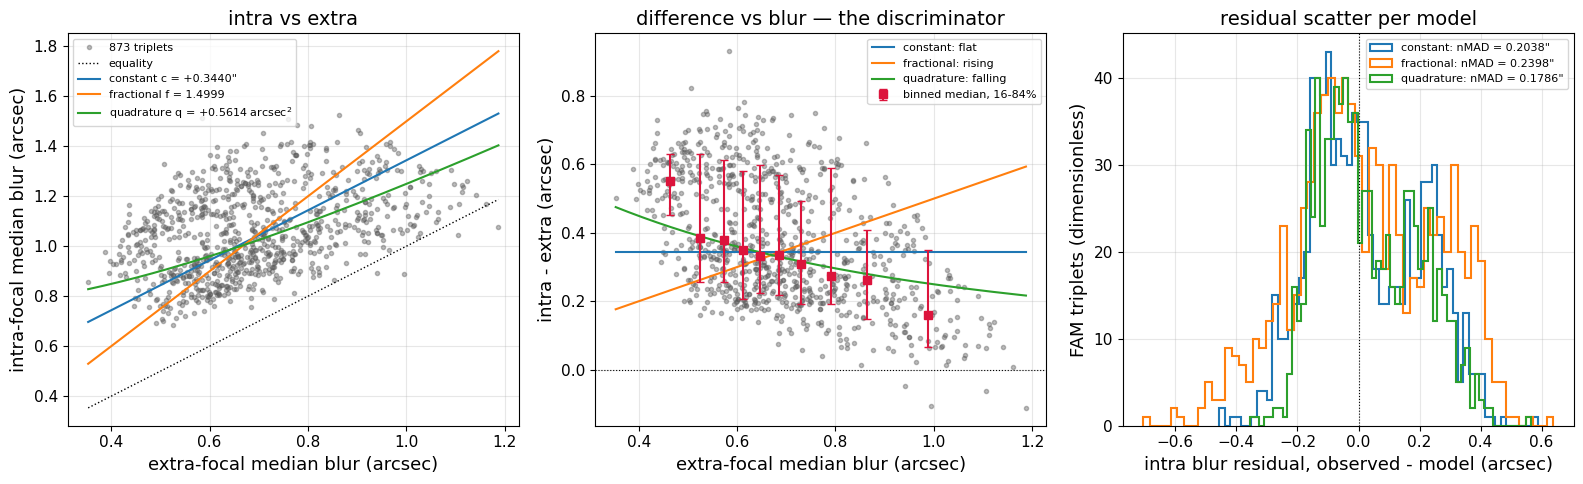

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

ok = np.isfinite(b_intra) & np.isfinite(b_extra)
bi, be = b_intra[ok], b_extra[ok]
grid = np.linspace(np.min(be), np.max(be), 200)

# Panel 1: intra against extra, with the three fitted relations.
ax = axs[0]
ax.plot(be, bi, linestyle='none', marker='o', markersize=3, alpha=0.4,
        color='0.35', label=f'{n_fit} triplets')
ax.plot(grid, grid, color='k', linewidth=1.0, linestyle=':', label='equality')
ax.plot(grid, grid + models['constant']['param'], color='#1f77b4', linewidth=1.5,
        label=f"constant c = {models['constant']['param']:+.4f}\"")
ax.plot(grid, models['fractional']['param'] * grid, color='#ff7f0e', linewidth=1.5,
        label=f"fractional f = {models['fractional']['param']:.4f}")
ax.plot(grid, np.sqrt(np.clip(grid**2 + models['quadrature']['param'], 0, None)),
        color='#2ca02c', linewidth=1.5,
        label=f"quadrature q = {models['quadrature']['param']:+.4f} arcsec$^2$")
ax.set_xlabel('extra-focal median blur (arcsec)')
ax.set_ylabel('intra-focal median blur (arcsec)')
ax.set_title('intra vs extra')
ax.legend(fontsize=8, loc='upper left')

# Panel 2: the discriminator — difference against extra blur.
ax = axs[1]
ax.plot(be, bi - be, linestyle='none', marker='o', markersize=3, alpha=0.4, color='0.35')
ax.axhline(0.0, color='k', linewidth=0.8, linestyle=':')
ax.plot(grid, np.full_like(grid, models['constant']['param']), color='#1f77b4',
        linewidth=1.5, label='constant: flat')
ax.plot(grid, (models['fractional']['param'] - 1.0) * grid, color='#ff7f0e',
        linewidth=1.5, label='fractional: rising')
ax.plot(grid, np.sqrt(np.clip(grid**2 + models['quadrature']['param'], 0, None)) - grid,
        color='#2ca02c', linewidth=1.5, label='quadrature: falling')

# Binned medians of the observed difference: the data's own answer, model-free.
edges = np.quantile(be, np.linspace(0, 1, 11))
centers, med, lo, hi = [], [], [], []
for a, b in zip(edges[:-1], edges[1:]):
    sel = (be >= a) & (be <= b) if b == edges[-1] else (be >= a) & (be < b)
    if sel.sum() >= 5:
        d = (bi - be)[sel]
        centers.append(float(np.median(be[sel])))
        med.append(float(np.median(d)))
        lo.append(float(np.percentile(d, 16)))
        hi.append(float(np.percentile(d, 84)))
med, lo, hi = np.array(med), np.array(lo), np.array(hi)
ax.errorbar(centers, med, yerr=[med - lo, hi - med], fmt='s', color='crimson',
            markersize=6, capsize=3, linewidth=1.5, label='binned median, 16-84%')
ax.set_xlabel('extra-focal median blur (arcsec)')
ax.set_ylabel('intra - extra (arcsec)')
ax.set_title('difference vs blur — the discriminator')
ax.legend(fontsize=8)

# Panel 3: residual distributions, one histogram per model.
ax = axs[2]
for name, color in (('constant', '#1f77b4'), ('fractional', '#ff7f0e'),
                    ('quadrature', '#2ca02c')):
    m = models[name]
    ax.hist(m['residual'], bins=60, histtype='step', linewidth=1.5, color=color,
            label=f"{name}: nMAD = {m['nmad_arcsec']:.4f}\"")
ax.axvline(0.0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel('intra blur residual, observed - model (arcsec)')
ax.set_ylabel('FAM triplets (dimensionless)')
ax.set_title('residual scatter per model')
ax.legend(fontsize=8)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_offset_models.pdf')
plt.show()


### Trend of the difference, quantified

The binned medians above are the direct test. Fitting a line to `intra - extra` against
extra blur separates the three models by its slope alone:

- slope ~ 0 with a non-zero intercept: **constant** offset
- slope ~ `f - 1` > 0 through the origin: **fractional** offset
- slope < 0: **quadrature** offset

Huber robust linear regression, the repository default for a calibration line of this
kind.


In [8]:
X = sm.add_constant(be)
rlm = sm.RLM(bi - be, X, M=sm.robust.norms.HuberT()).fit()
intercept, slope = float(rlm.params[0]), float(rlm.params[1])
intercept_err, slope_err = float(rlm.bse[0]), float(rlm.bse[1])

print(f'Huber RLM of (intra - extra) in arcsec on extra blur in arcsec, '
      f'n = {n_fit} triplets')
print(f'  intercept = {intercept:+.5f} +/- {intercept_err:.5f} arcsec')
print(f'  slope     = {slope:+.5f} +/- {slope_err:.5f} arcsec per arcsec '
      f'(dimensionless)')
print(f'  a fractional offset would predict slope = '
      f'{models["fractional"]["param"] - 1.0:+.5f} (dimensionless)')
print(f'  a constant offset would predict slope = +0.00000 (dimensionless)')

r, p_r = stats.pearsonr(be, bi - be)
rho, p_rho = stats.spearmanr(be, bi - be)
print(f'\n(intra - extra) in arcsec vs extra blur in arcsec, n = {n_fit} triplets:')
print(f'  Pearson r    = {r:+.4f} (p = {p_r:.3e})')
print(f'  Spearman rho = {rho:+.4f} (p = {p_rho:.3e})')

r2, p_r2 = stats.pearsonr(be, bi)
rho2, p_rho2 = stats.spearmanr(be, bi)
print(f'\nintra blur vs extra blur, both arcsec, n = {n_fit} triplets:')
print(f'  Pearson r    = {r2:+.4f} (p = {p_r2:.3e})')
print(f'  Spearman rho = {rho2:+.4f} (p = {p_rho2:.3e})')


Huber RLM of (intra - extra) in arcsec on extra blur in arcsec, n = 873 triplets
  intercept = +0.76206 +/- 0.02435 arcsec
  slope     = -0.57640 +/- 0.03444 arcsec per arcsec (dimensionless)
  a fractional offset would predict slope = +0.49989 (dimensionless)
  a constant offset would predict slope = +0.00000 (dimensionless)

(intra - extra) in arcsec vs extra blur in arcsec, n = 873 triplets:
  Pearson r    = -0.5061 (p = 5.627e-58)
  Spearman rho = -0.4830 (p = 3.181e-52)

intra blur vs extra blur, both arcsec, n = 873 triplets:
  Pearson r    = +0.4003 (p = 6.156e-35)
  Spearman rho = +0.3934 (p = 1.096e-33)


<a id='thermal'></a>
## 7. Thermal dependence of the difference

Aaron's hypothesis: thermal effects move light around inside the donut, so the intra/extra
asymmetry should track the telescope's thermal state. This section tests it visit by visit.

**The target is the arithmetic difference, in arcsec:**

```
blur_diff_arcsec = b_intra - b_extra             [arcsec]
```

Section 6 found little to choose between the constant and quadrature models, so the
simpler of the two is used here: a plain subtraction, in arcsec, with nothing subtracted
beyond that — no night mean and no fitted model. Slopes below are therefore arcsec of
blur difference per unit of the thermal quantity, and are comparable to the
constant-offset parameter `c` in section 6.

A handful of triplets have the intra side sharper and so come out negative. They are
kept.

**Telemetry is per exposure, and now genuinely so.** `visits.parquet` carries
`intra_visit` and `extra_visit`, so each side's telemetry is joined on its own exposure
identifier. The per-triplet value used below is the mean of the two sides; the difference
between them is examined separately in section 7.5.

**One caveat kept from the earlier version of this section.** Both the thermal state and
the seeing drift slowly, so they are both near-constant within a night and differ strongly
between nights. A quantity that is merely cold on the large-difference nights will
correlate across the whole sample without being a cause. The ranking below is on the
full sample as asked, but every table also carries the within-night coefficient — the same
statistic with each night's mean removed from both variables. Where the two disagree
sharply, the full-sample number is the night, not the physics.


In [9]:
# ============================================================
# Thermal telemetry, joined per side of focus
# ============================================================
# ConsDB is the slow step, so the join is cached beside the plots. The filename changes
# whenever the fetched column set does, because an older cache would silently be reused
# and the new columns would come back all-NaN.
THERMAL_CACHE = OUT_DIR / 'thermal_join_per_side_cam.parquet'

GRAD_SQL_COLS = ('m1m3_x_gradient_c_per_m', 'm1m3_y_gradient_c_per_m',
                 'm1m3_z_gradient_c_per_m', 'm1m3_radial_gradient_c_per_m')
R2_SQL_COLS = ('m1m3_r2_coeff_c', 'm1m3_rms_c', 'm1m3_mean_temp_c', 'm1m3_std_temp_c',
               'm1m3_range_temp_c', 'm1_mean_temp_c', 'm3_mean_temp_c')
#: Camera-body temperature, from the camera's own housekeeping topic rather than from an
#: ESS air sensor. `cam_AverageTemp` is the camera's average over its body thermometers;
#: `cam_air_temp` below is the ESS air beside the camera and is a different quantity.
CAM_SQL_COLS = ('cam_AverageTemp',)
#: Columns fetched per exposure and then averaged / differenced across the two sides.
PER_SIDE_COLS = (['m1m3_air_temp', 'm2_air_temp', 'cam_air_temp', 'outside_temp',
                  'truss_temp_mean_c'] + list(GRAD_SQL_COLS) + list(R2_SQL_COLS)
                 + list(CAM_SQL_COLS))

if THERMAL_CACHE.exists():
    per_side = pd.read_parquet(THERMAL_CACHE)
    print(f'per-side thermal telemetry read from {THERMAL_CACHE.name}: {per_side.shape}')
else:
    sys.path.insert(0, str(_TOPIC.parent / 'value_added' / 'code'))
    import efd_db

    sides = pd.read_parquet(visits_file,
                            columns=['visit', 'day_obs', 'seq_num',
                                     'intra_visit', 'extra_visit'])

    def _fetch(exposure_ids):
        """ConsDB air/truss temperatures and DuckDB M1M3 terms for a set of exposures."""
        req = pd.DataFrame({'visit_id': np.asarray(exposure_ids, dtype=np.int64)})
        # day_obs is needed by interpolate_within_night inside join_consdb.
        req['day_obs'] = req['visit_id'] // 100000
        req['seq_num'] = req['visit_id'] % 100000
        got = efd_db.join_consdb(req, groups=('thermal',))
        con = efd_db.open_db()
        try:
            ids = ', '.join(str(int(x)) for x in req['visit_id'])
            grads = con.execute(
                f'SELECT visit_id, {", ".join(GRAD_SQL_COLS + CAM_SQL_COLS)} '
                f'FROM visit_telemetry WHERE visit_id IN ({ids})').fetchdf()
            r2 = con.execute(
                f'SELECT visit_id, {", ".join(R2_SQL_COLS)} '
                f'FROM m1m3_thermal_r2 WHERE visit_id IN ({ids})').fetchdf()
        finally:
            con.close()
        return got.merge(grads, on='visit_id', how='left').merge(
            r2, on='visit_id', how='left')

    keep = ['visit_id'] + [c for c in PER_SIDE_COLS]
    intra = _fetch(sides['intra_visit'])
    extra = _fetch(sides['extra_visit'])
    intra = intra[[c for c in keep if c in intra.columns]]
    extra = extra[[c for c in keep if c in extra.columns]]

    per_side = sides.merge(intra.add_suffix('_intra'),
                           left_on='intra_visit', right_on='visit_id_intra', how='left')
    per_side = per_side.merge(extra.add_suffix('_extra'),
                              left_on='extra_visit', right_on='visit_id_extra',
                              how='left')
    per_side.to_parquet(THERMAL_CACHE, index=False)
    print(f'per-side thermal telemetry fetched and cached to {THERMAL_CACHE.name}: '
          f'{per_side.shape}')

# `v` already carries intra_visit / extra_visit from visits.parquet, so the shared
# identity columns are dropped from the right side rather than suffixed.
_drop = [c for c in ('day_obs', 'seq_num', 'intra_visit', 'extra_visit',
                     'visit_id_intra', 'visit_id_extra')
         if c in per_side.columns]
d = v.merge(per_side.drop(columns=_drop), on='visit', how='left')

# The per-triplet value of each quantity is the mean of the two exposures, and the
# per-side difference is kept alongside for section 7.5.
avail = [c for c in PER_SIDE_COLS
         if f'{c}_intra' in d.columns and f'{c}_extra' in d.columns]
for c in avail:
    d[c] = 0.5 * (d[f'{c}_intra'] + d[f'{c}_extra'])
    d[f'{c}_side_diff'] = d[f'{c}_intra'] - d[f'{c}_extra']

# The temperature differences Aaron named. Signs are fixed here so every panel reads the
# same way, and the glass-minus-air pair is now available because m1m3_mean_temp_c exists.
d['truss_minus_m1m3_air_c'] = d['truss_temp_mean_c'] - d['m1m3_air_temp']
d['truss_minus_m2_air_c'] = d['truss_temp_mean_c'] - d['m2_air_temp']
d['m2_minus_m1m3_air_c'] = d['m2_air_temp'] - d['m1m3_air_temp']
d['cam_minus_m1m3_air_c'] = d['cam_air_temp'] - d['m1m3_air_temp']
d['m2_air_minus_outside_c'] = d['m2_air_temp'] - d['outside_temp']
d['m1m3_glass_minus_air_c'] = d['m1m3_mean_temp_c'] - d['m1m3_air_temp']
d['m1_glass_minus_air_c'] = d['m1_mean_temp_c'] - d['m1m3_air_temp']
d['m3_glass_minus_air_c'] = d['m3_mean_temp_c'] - d['m1m3_air_temp']
d['m1_minus_m3_glass_c'] = d['m1_mean_temp_c'] - d['m3_mean_temp_c']
# Camera body against the M1M3 air. A difference rather than a level, so it is less
# likely than cam_AverageTemp itself to act as a proxy for which night it is.
d['cam_body_minus_m1m3_air_c'] = d['cam_AverageTemp'] - d['m1m3_air_temp']

# The target: the arithmetic difference, nothing subtracted. Triplets where the intra
# side is sharper give a negative value and are kept.
d['blur_diff_arcsec'] = (d['median_blur_intra_arcsec']
                         - d['median_blur_extra_arcsec'])

THERMAL_FEATURES = {
    'm1m3_glass_minus_air_c': 'M1M3 glass - M1M3 air (deg C)',
    'm1_glass_minus_air_c': 'M1 glass - M1M3 air (deg C)',
    'm3_glass_minus_air_c': 'M3 glass - M1M3 air (deg C)',
    'm1_minus_m3_glass_c': 'M1 glass - M3 glass (deg C)',
    'm1m3_mean_temp_c': 'M1M3 glass temperature (deg C)',
    'truss_minus_m1m3_air_c': 'truss - M1M3 air (deg C)',
    'truss_minus_m2_air_c': 'truss - M2 air (deg C)',
    'm2_minus_m1m3_air_c': 'M2 air - M1M3 air (deg C)',
    'cam_minus_m1m3_air_c': 'camera air - M1M3 air (deg C)',
    'cam_AverageTemp': 'camera body average temperature (deg C)',
    'cam_body_minus_m1m3_air_c': 'camera body - M1M3 air (deg C)',
    'm2_air_minus_outside_c': 'M2 air - outside (deg C)',
    'm1m3_x_gradient_c_per_m': 'M1M3 x gradient (deg C/m)',
    'm1m3_y_gradient_c_per_m': 'M1M3 y gradient (deg C/m)',
    'm1m3_z_gradient_c_per_m': 'M1M3 z gradient (deg C/m)',
    'm1m3_radial_gradient_c_per_m': 'M1M3 radial gradient (deg C/m)',
    'm1m3_r2_coeff_c': 'M1M3 quadratic-in-radius (deg C)',
    'm1m3_std_temp_c': 'M1M3 thermocouple scatter (deg C)',
    'm1m3_range_temp_c': 'M1M3 thermocouple range (deg C)',
    'truss_temp_mean_c': 'mean truss temperature (deg C)',
    'm1m3_air_temp': 'M1M3 air temperature (deg C)',
    'outside_temp': 'outside air temperature (deg C)',
}

n_q = int(np.isfinite(d['blur_diff_arcsec']).sum())
n_neg = int((d['blur_diff_arcsec'] < 0).sum())
print(f'\nblur difference (intra - extra): {n_q} triplets with a finite value, '
      f'{n_neg} negative (intra sharper than extra)')
print(f'  median {np.nanmedian(d["blur_diff_arcsec"]):+.5f} arcsec, '
      f'range {np.nanmin(d["blur_diff_arcsec"]):+.5f} to '
      f'{np.nanmax(d["blur_diff_arcsec"]):+.5f} arcsec')
print(f'  robust scatter (nMAD) = {nmad(d["blur_diff_arcsec"].dropna()):.5f} arcsec')
print(f'\n{len(THERMAL_FEATURES)} thermal quantities, coverage out of {len(d)} triplets:')
for c, lab in THERMAL_FEATURES.items():
    print(f'  {lab:38s} {int(np.isfinite(d[c]).sum()):4d}')


        Use pytest instead. [astropy.tests.runner]
        Use pytest instead.


        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead.


per-side thermal telemetry fetched and cached to thermal_join_per_side_cam.parquet: (966, 41)

blur difference (intra - extra): 873 triplets with a finite value, 4 negative (intra sharper than extra)
  median +0.34395 arcsec, range -0.11160 to +0.93080 arcsec
  robust scatter (nMAD) = 0.20379 arcsec

22 thermal quantities, coverage out of 873 triplets:
  M1M3 glass - M1M3 air (deg C)           871
  M1 glass - M1M3 air (deg C)             871
  M3 glass - M1M3 air (deg C)             871
  M1 glass - M3 glass (deg C)             873
  M1M3 glass temperature (deg C)          873
  truss - M1M3 air (deg C)                871
  truss - M2 air (deg C)                  871
  M2 air - M1M3 air (deg C)               871
  camera air - M1M3 air (deg C)           871
  camera body average temperature (deg C)  855
  camera body - M1M3 air (deg C)          853
  M2 air - outside (deg C)                871
  M1M3 x gradient (deg C/m)               873
  M1M3 y gradient (deg C/m)               873


### 7.1 One variable at a time, ranked by Spearman rho

A Huber robust linear fit of the blur difference `intra - extra` on each thermal
quantity alone.
Sorted by |Spearman rho| on the full sample, which is the ranking that drives the
cumulative build-up in 7.2.

The last two columns are the same correlation with each night's mean removed. A variable
whose full-sample rho is large while its within-night rho is near zero is tracking the
night, not the donut.

In [10]:
def rank_single_fits(frame, features, target, min_per_night=MIN_NIGHT_TRIPLETS):
    """Huber fit and correlations of a target against each thermal quantity separately.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        One row per FAM triplet, carrying ``day_obs``, `target` and every feature column.
    features : `dict` [`str`, `str`]
        Column name to label; the label names the quantity and its units.
    target : `str`
        Target column, in arcsec.
    min_per_night : `int`, optional
        Nights with fewer triplets are excluded from the within-night columns,
        dimensionless.

    Returns
    -------
    table : `pandas.DataFrame`
        One row per feature sorted by descending |full-sample Spearman rho|, carrying the
        Huber slope and its error in arcsec per unit of the feature, the full-sample
        Pearson r and Spearman rho, the within-night Pearson r and Spearman rho (all
        dimensionless), the triplet count and the night count.
    """
    rows = []
    for col, label in features.items():
        ok = np.isfinite(frame[col]) & np.isfinite(frame[target])
        sub = frame[ok]
        if len(sub) < 20:
            continue
        x = sub[col].to_numpy(float)
        y = sub[target].to_numpy(float)
        fit = sm.RLM(y, sm.add_constant(x), M=sm.robust.norms.HuberT()).fit()
        r, _ = stats.pearsonr(x, y)
        rho, _ = stats.spearmanr(x, y)

        counts = sub.groupby('day_obs')[col].transform('size')
        wn = sub[counts >= min_per_night]
        if len(wn) >= 20:
            xw = wn[col] - wn.groupby('day_obs')[col].transform('mean')
            yw = wn[target] - wn.groupby('day_obs')[target].transform('mean')
            r_wn, _ = stats.pearsonr(xw, yw)
            rho_wn, _ = stats.spearmanr(xw, yw)
            n_nights = int(wn['day_obs'].nunique())
        else:
            r_wn = rho_wn = np.nan
            n_nights = 0
        rows.append({'column': col, 'feature': label, 'n': int(len(sub)),
                     'slope': float(fit.params[1]), 'slope_err': float(fit.bse[1]),
                     'pearson_r': r, 'spearman_rho': rho,
                     'pearson_r_within_night': r_wn,
                     'spearman_rho_within_night': rho_wn, 'n_nights': n_nights})
    table = pd.DataFrame(rows)
    return table.reindex(
        table['spearman_rho'].abs().sort_values(ascending=False).index
    ).reset_index(drop=True)


ranked = rank_single_fits(d, THERMAL_FEATURES, 'blur_diff_arcsec')

print('Huber fit of the blur difference (intra - extra) in arcsec on each thermal '
      'quantity alone,')
print('sorted by |Spearman rho| on the full sample.\n')
hdr = (f'{"quantity":38s} {"n":>4s} {"slope (arcsec/unit)":>22s} {"r":>8s} '
       f'{"rho":>8s} {"rho wn":>8s} {"nights":>7s}')
print(hdr)
print('-' * len(hdr))
for _, row in ranked.iterrows():
    print(f'{row["feature"]:38s} {row["n"]:4d} '
          f'{row["slope"]:+10.5f} +/- {row["slope_err"]:7.5f} '
          f'{row["pearson_r"]:+8.4f} {row["spearman_rho"]:+8.4f} '
          f'{row["spearman_rho_within_night"]:+8.4f} {row["n_nights"]:7d}')
print('\nslope: arcsec per unit of the quantity named in the first column.')
print('r, rho: dimensionless. "rho wn" is Spearman rho with each night\'s mean removed.')


Huber fit of the blur difference (intra - extra) in arcsec on each thermal quantity alone,
sorted by |Spearman rho| on the full sample.

quantity                                  n    slope (arcsec/unit)        r      rho   rho wn  nights
-----------------------------------------------------------------------------------------------------
camera body - M1M3 air (deg C)          853   -0.23819 +/- 0.00723  -0.7576  -0.7828  -0.2934      13
truss - M1M3 air (deg C)                871   -0.28960 +/- 0.00985  -0.7019  -0.6990  -0.3566      14
M1M3 air temperature (deg C)            871   +0.04835 +/- 0.00227  +0.6124  +0.6125  +0.1540      14
outside air temperature (deg C)         871   +0.04646 +/- 0.00210  +0.6240  +0.6092  +0.0155      14
M1M3 y gradient (deg C/m)               873  +10.08383 +/- 0.53066  +0.5517  +0.5422  +0.3809      14
M1M3 glass temperature (deg C)          873   +0.04123 +/- 0.00237  +0.5269  +0.5305  +0.2941      14
M2 air - outside (deg C)                871   -

### 7.2 Adding the variables one at a time

Starting from the top-ranked quantity, each next-ranked quantity is added to a joint
Huber fit of the blur difference and the result reported. Two guards keep the exercise honest:

- **Redundancy.** The air differences share the M1M3 sensor and the gradients share one
  thermocouple grid, so a candidate already implied by what is in the model adds nothing
  but noise. A candidate whose variance inflation factor against the variables already
  included exceeds `MAX_VIF` is skipped, and the skip is printed.
- **Where to stop.** Adding variables can only reduce the in-sample residual, so "the
  scatter went down" is not evidence on its own. The step is only kept if it reduces the
  residual nMAD by at least `MIN_NMAD_GAIN` of its current value.

In [11]:
MAX_VIF = 10.0        # dimensionless; variance inflation factor against those already in
MIN_NMAD_GAIN = 0.01  # dimensionless; required fractional drop in residual nMAD per step


def vif(frame, candidate, chosen):
    """Variance inflation factor of one candidate column against those already chosen.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        Rows with every column finite.
    candidate : `str`
        Column being considered.
    chosen : `list` [`str`]
        Columns already in the model.

    Returns
    -------
    value : `float`
        ``1 / (1 - R^2)`` of the candidate regressed on `chosen`, dimensionless. 1.0 means
        orthogonal to them; large means already implied by them. Returns 1.0 when `chosen`
        is empty.
    """
    if not chosen:
        return 1.0
    y = frame[candidate].to_numpy(float)
    X = sm.add_constant(frame[chosen].to_numpy(float))
    r2 = sm.OLS(y, X).fit().rsquared
    return float('inf') if r2 >= 1.0 else 1.0 / (1.0 - r2)


def cumulative_fit(frame, ranked_table, target, max_vif=MAX_VIF,
                   min_gain=MIN_NMAD_GAIN):
    """Add thermal quantities to a joint Huber fit in rank order, one at a time.

    Parameters
    ----------
    frame : `pandas.DataFrame`
        One row per FAM triplet.
    ranked_table : `pandas.DataFrame`
        Output of `rank_single_fits`, already in the desired order.
    target : `str`
        Target column, in arcsec.
    max_vif : `float`, optional
        A candidate with a higher variance inflation factor against the already-chosen
        columns is skipped, dimensionless.
    min_gain : `float`, optional
        Minimum fractional reduction in residual nMAD for a step to be kept,
        dimensionless.

    Returns
    -------
    steps : `list` [`dict`]
        One entry per accepted step: the columns in the model, the fit, the prediction,
        the observed target, the residual nMAD in arcsec, and the Pearson r and Spearman
        rho of prediction against observed (dimensionless).
    skipped : `list` [`dict`]
        Candidates not accepted, each with the reason.
    """
    chosen, steps, skipped = [], [], []
    for _, row in ranked_table.iterrows():
        trial = chosen + [row['column']]
        ok = np.isfinite(frame[target])
        for c in trial:
            ok &= np.isfinite(frame[c])
        sub = frame[ok]
        if len(sub) < 50:
            skipped.append({'feature': row['feature'],
                            'reason': f'only {len(sub)} triplets with every column finite'})
            continue
        v = vif(sub, row['column'], chosen)
        if v > max_vif:
            skipped.append({'feature': row['feature'],
                            'reason': f'variance inflation factor {v:.1f} '
                                      f'(dimensionless) against the model so far'})
            continue
        y = sub[target].to_numpy(float)
        X = sm.add_constant(sub[trial].to_numpy(float))
        fit = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
        pred = fit.fittedvalues
        resid_nmad = float(nmad(y - pred))
        prev = steps[-1]['resid_nmad'] if steps else float(nmad(y - np.median(y)))
        if steps and resid_nmad > prev * (1.0 - min_gain):
            skipped.append({'feature': row['feature'],
                            'reason': f'residual nMAD {resid_nmad:.5f} arcsec against '
                                      f'{prev:.5f} arcsec, gain below '
                                      f'{min_gain:.0%} of it'})
            continue
        chosen = trial
        r, _ = stats.pearsonr(pred, y)
        rho, _ = stats.spearmanr(pred, y)
        steps.append({'columns': list(chosen), 'added': row['column'],
                      'added_label': row['feature'], 'fit': fit, 'pred': pred, 'y': y,
                      'sub': sub, 'resid_nmad': resid_nmad, 'baseline_nmad': prev,
                      'pearson_r': r, 'spearman_rho': rho, 'n': int(len(sub))})
    return steps, skipped


steps, skipped = cumulative_fit(d, ranked, 'blur_diff_arcsec')

label_of = dict(zip(ranked['column'], ranked['feature']))
print('Cumulative Huber fit of the blur difference (intra - extra) in arcsec.\n')
for i, s in enumerate(steps, start=1):
    print(f'step {i}: + {s["added_label"]}')
    print(f'  {len(s["columns"])} variable(s), n = {s["n"]} triplets')
    print(f'  residual nMAD {s["baseline_nmad"]:.5f} -> {s["resid_nmad"]:.5f} arcsec')
    print(f'  prediction vs observed: Pearson r = {s["pearson_r"]:+.4f}, '
          f'Spearman rho = {s["spearman_rho"]:+.4f} (dimensionless)')
    for j, c in enumerate(s['columns']):
        unit = label_of[c].split('(')[-1].rstrip(')')
        print(f'    {label_of[c]:38s} slope = {s["fit"].params[j + 1]:+10.5f} '
              f'+/- {s["fit"].bse[j + 1]:8.5f} arcsec per {unit}')
    print()

if skipped:
    print('Not added:')
    for s in skipped:
        print(f'  {s["feature"]:38s} {s["reason"]}')


Cumulative Huber fit of the blur difference (intra - extra) in arcsec.

step 1: + camera body - M1M3 air (deg C)
  1 variable(s), n = 853 triplets
  residual nMAD 0.20405 -> 0.11432 arcsec
  prediction vs observed: Pearson r = +0.7576, Spearman rho = +0.7828 (dimensionless)
    camera body - M1M3 air (deg C)         slope =   -0.23819 +/-  0.00723 arcsec per deg C

step 2: + truss - M1M3 air (deg C)
  2 variable(s), n = 853 triplets
  residual nMAD 0.11432 -> 0.11251 arcsec
  prediction vs observed: Pearson r = +0.7617, Spearman rho = +0.7849 (dimensionless)
    camera body - M1M3 air (deg C)         slope =   -0.18900 +/-  0.01451 arcsec per deg C
    truss - M1M3 air (deg C)               slope =   -0.07560 +/-  0.01896 arcsec per deg C

step 3: + M1M3 air temperature (deg C)
  3 variable(s), n = 853 triplets
  residual nMAD 0.11251 -> 0.10308 arcsec
  prediction vs observed: Pearson r = +0.7844, Spearman rho = +0.8057 (dimensionless)
    camera body - M1M3 air (deg C)         slope 

### 7.3 The scatter plot at each step

Observed blur difference against the cumulative prediction, one panel per accepted
step. Colour is `day_obs`. The dotted line is one-to-one.

/lscratch/roodman/ipykernel_3593907/2874634235.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


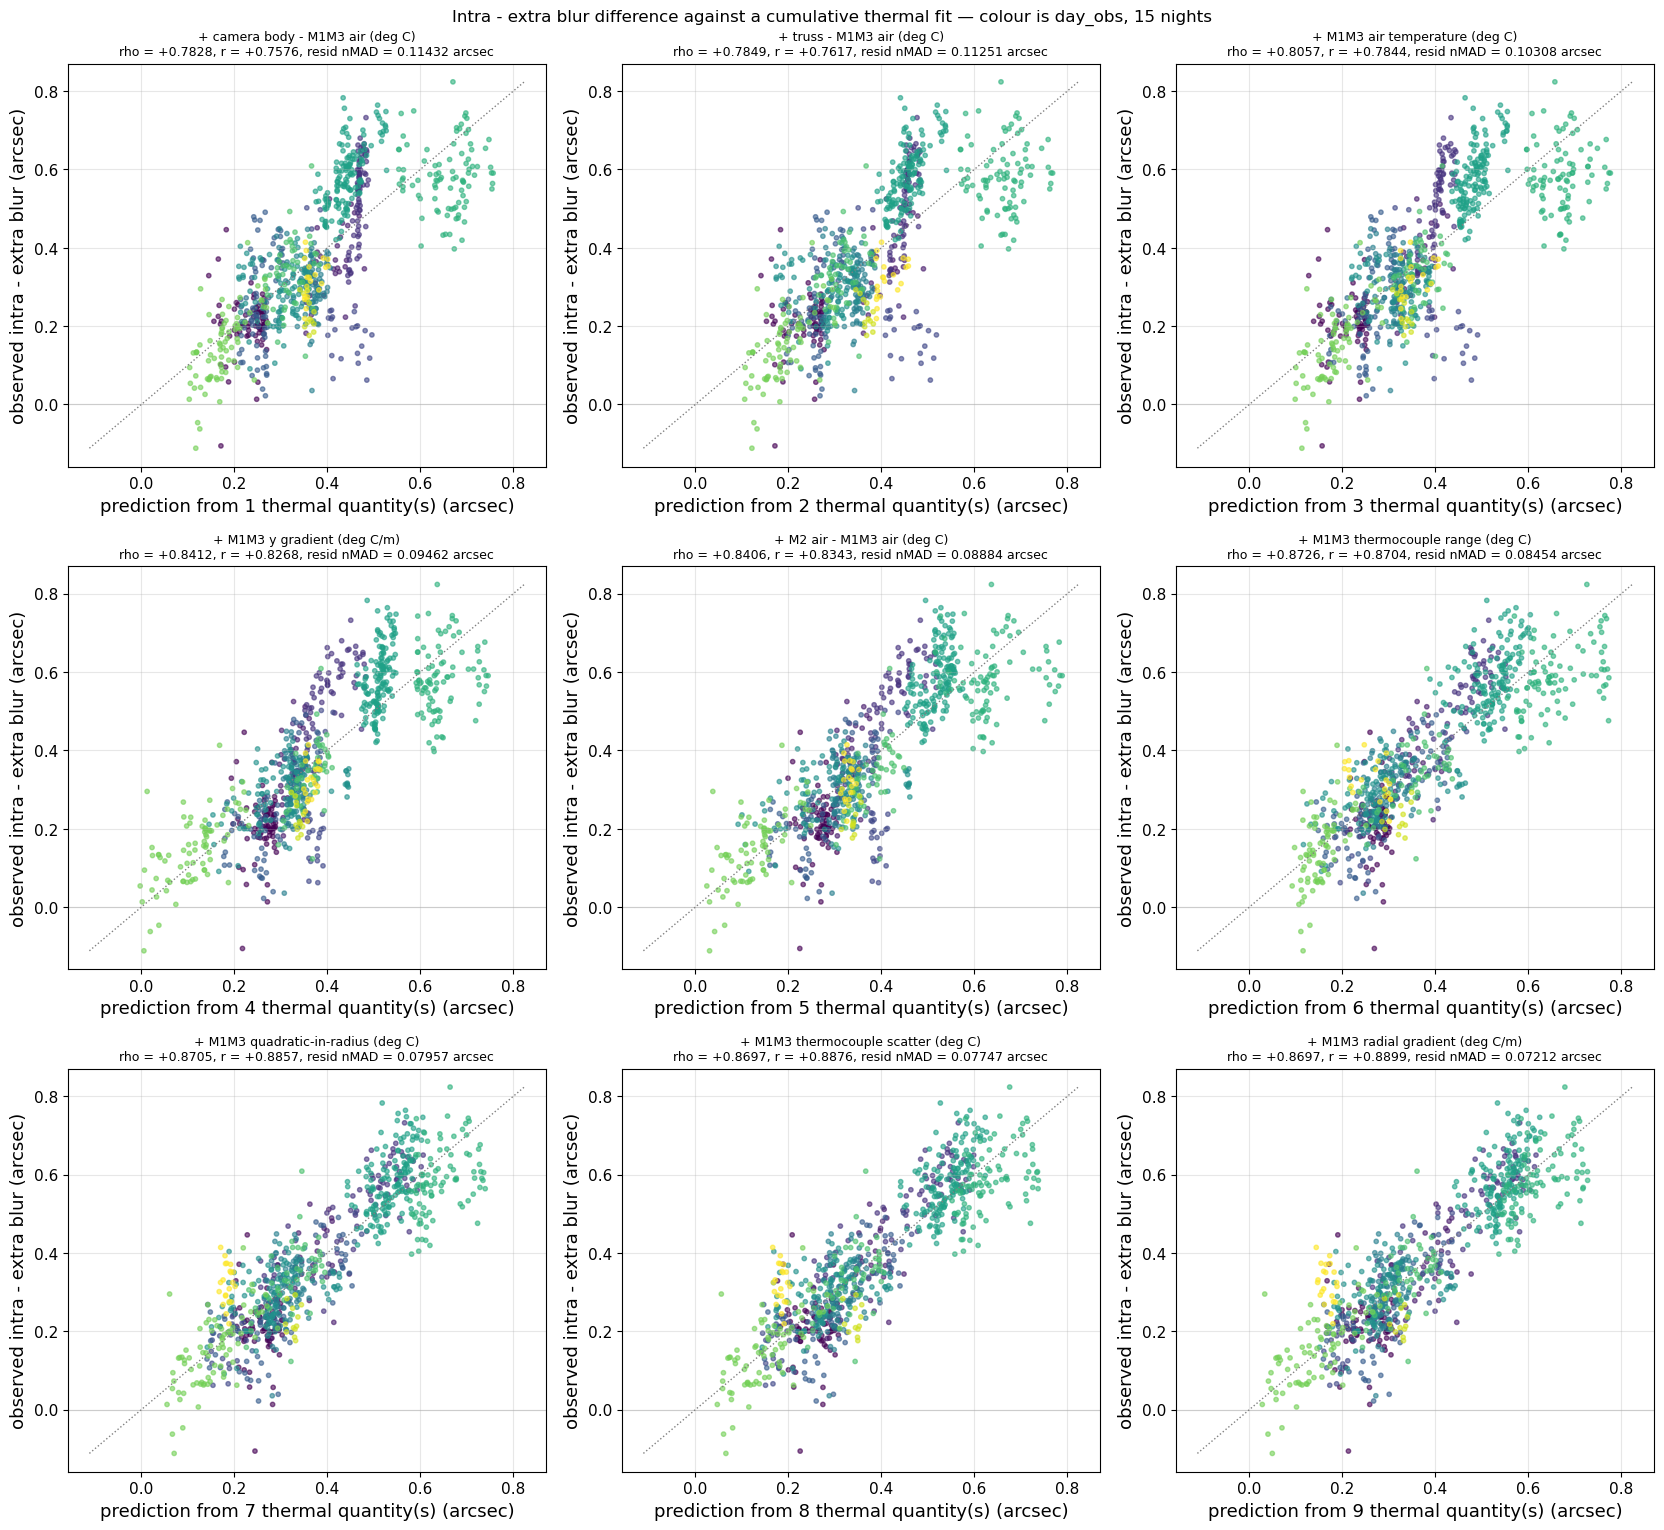

In [12]:
n_steps = len(steps)
ncol = min(3, n_steps)
nrow = int(np.ceil(n_steps / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(5.6 * ncol, 5.2 * nrow), squeeze=False)

nights = sorted(d['day_obs'].dropna().unique())
cmap = plt.get_cmap('viridis')
night_color = {n: cmap(i / max(len(nights) - 1, 1)) for i, n in enumerate(nights)}

for ax, s in zip(axs.ravel(), steps):
    sub = s['sub']
    ax.scatter(s['pred'], s['y'], s=10, alpha=0.6,
               c=[night_color[n] for n in sub['day_obs']])
    lo = float(min(np.min(s['pred']), np.min(s['y'])))
    hi = float(max(np.max(s['pred']), np.max(s['y'])))
    ax.plot([lo, hi], [lo, hi], color='0.5', linestyle=':', linewidth=1.0)
    ax.axhline(0.0, color='0.85', linewidth=0.8, zorder=0)
    ax.set_xlabel(f'prediction from {len(s["columns"])} thermal quantity(s) (arcsec)')
    ax.set_ylabel('observed intra - extra blur (arcsec)')
    ax.set_title(f'+ {s["added_label"]}\n'
                 f'rho = {s["spearman_rho"]:+.4f}, r = {s["pearson_r"]:+.4f}, '
                 f'resid nMAD = {s["resid_nmad"]:.5f} arcsec', fontsize=9)

for ax in axs.ravel()[n_steps:]:
    ax.set_visible(False)

fig.suptitle('Intra - extra blur difference against a cumulative thermal '
             f'fit — colour is day_obs, {len(nights)} nights', fontsize=12)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_diff_thermal_cumulative.pdf')
plt.show()


### 7.4 The final model

The set the build-up settled on, with every slope in arcsec per unit of its quantity.

Final model: 9 thermal quantities, n = 853 triplets over 14 nights

  camera body - M1M3 air (deg C)         slope =   +0.01216 +/-  0.01647 arcsec per deg C
  truss - M1M3 air (deg C)               slope =   -0.17454 +/-  0.01657 arcsec per deg C
  M1M3 air temperature (deg C)           slope =   +0.02004 +/-  0.00216 arcsec per deg C
  M1M3 y gradient (deg C/m)              slope =   +7.52013 +/-  0.60621 arcsec per deg C/m
  M2 air - M1M3 air (deg C)              slope =   +0.03746 +/-  0.01339 arcsec per deg C
  M1M3 thermocouple range (deg C)        slope =   +0.40779 +/-  0.04450 arcsec per deg C
  M1M3 quadratic-in-radius (deg C)       slope =   -3.63000 +/-  0.31248 arcsec per deg C
  M1M3 thermocouple scatter (deg C)      slope =   -0.63845 +/-  0.14070 arcsec per deg C
  M1M3 radial gradient (deg C/m)         slope =   +2.58732 +/-  0.54441 arcsec per deg C/m

  intercept = -0.27995 arcsec

observed blur difference, robust scatter (nMAD) about its median = 0.20405 arcsec
resi

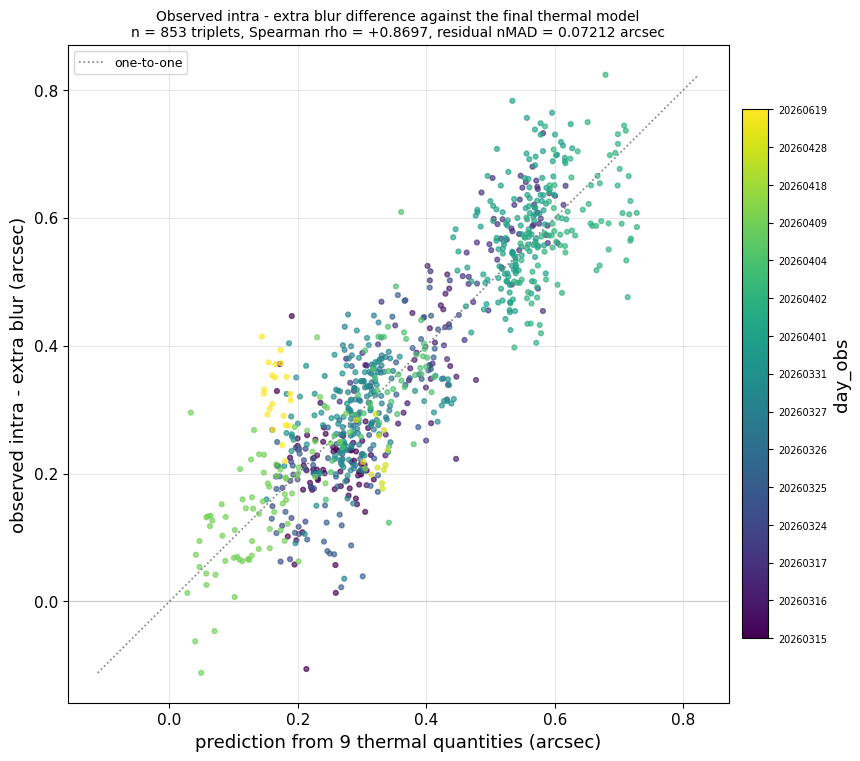

In [13]:
final = steps[-1]
sub = final['sub']

print(f'Final model: {len(final["columns"])} thermal quantities, '
      f'n = {final["n"]} triplets over {sub["day_obs"].nunique()} nights\n')
for j, c in enumerate(final['columns']):
    unit = label_of[c].split('(')[-1].rstrip(')')
    print(f'  {label_of[c]:38s} slope = {final["fit"].params[j + 1]:+10.5f} '
          f'+/- {final["fit"].bse[j + 1]:8.5f} arcsec per {unit}')
print(f'\n  intercept = {final["fit"].params[0]:+.5f} arcsec')
print(f'\nobserved blur difference, robust scatter (nMAD) about its median '
      f'= {nmad(final["y"] - np.median(final["y"])):.5f} arcsec')
print(f'residual after the thermal model                            '
      f'= {final["resid_nmad"]:.5f} arcsec')
print(f'reduction = '
      f'{1.0 - final["resid_nmad"] / nmad(final["y"] - np.median(final["y"])):.4f} '
      f'(dimensionless, fraction of robust scatter in arcsec, not of variance)')
print(f'\nprediction vs observed: Pearson r = {final["pearson_r"]:+.4f}, '
      f'Spearman rho = {final["spearman_rho"]:+.4f} (dimensionless)')

# How much of this is night-level covariance rather than a within-night relation: the same
# model's prediction and the observation, both de-meaned by night.
yw = final['y'] - sub.groupby('day_obs')[ 'blur_diff_arcsec'].transform('mean').to_numpy()
pw = final['pred'] - pd.Series(final['pred'], index=sub.index).groupby(
    sub['day_obs']).transform('mean').to_numpy()
keep = sub.groupby('day_obs')['blur_diff_arcsec'].transform('size').to_numpy() >= \
    MIN_NIGHT_TRIPLETS
rho_wn, _ = stats.spearmanr(pw[keep], yw[keep])
r_wn, _ = stats.pearsonr(pw[keep], yw[keep])
print(f'\nsame model with each night\'s mean removed from both sides, '
      f'n = {int(keep.sum())} triplets:')
print(f'  Pearson r = {r_wn:+.4f}, Spearman rho = {rho_wn:+.4f} (dimensionless)')
print(f'  residual nMAD = {nmad(yw[keep] - pw[keep]):.5f} arcsec against '
      f'{nmad(yw[keep]):.5f} arcsec de-meaned but unmodelled')

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.scatter(final['pred'], final['y'], s=12, alpha=0.65,
           c=[night_color[n] for n in sub['day_obs']])
lo = float(min(np.min(final['pred']), np.min(final['y'])))
hi = float(max(np.max(final['pred']), np.max(final['y'])))
ax.plot([lo, hi], [lo, hi], color='0.5', linestyle=':', linewidth=1.2,
        label='one-to-one')
ax.axhline(0.0, color='0.85', linewidth=0.8, zorder=0)
ax.set_xlabel(f'prediction from {len(final["columns"])} thermal quantities (arcsec)')
ax.set_ylabel('observed intra - extra blur (arcsec)')
ax.set_title(f'Observed intra - extra blur difference against the final thermal '
             f'model\nn = {final["n"]} triplets, Spearman rho = '
             f'{final["spearman_rho"]:+.4f}, residual nMAD = '
             f'{final["resid_nmad"]:.5f} arcsec', fontsize=10)
ax.legend(fontsize=9, loc='upper left')

sm_ = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, len(nights) - 1))
cb = fig.colorbar(sm_, ax=ax, fraction=0.04, pad=0.02)
cb.set_ticks(range(len(nights)))
cb.set_ticklabels([str(int(n)) for n in nights], fontsize=7)
cb.set_label('day_obs')

# No tight_layout here: the colorbar sets its own layout engine and the two conflict.
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_diff_thermal_final.pdf', bbox_inches='tight')
plt.show()


### 7.5 Does the telemetry differ between the two exposures?

The new `intra_visit` / `extra_visit` columns make this testable for the first time. If
the asymmetry has a thermal cause that acts *between* the two exposures, the thermal
quantities should themselves differ between them. The two exposures are about a minute
apart while these quantities drift over tens of minutes, so the expectation is that the
per-side difference is tiny — the point is to measure it rather than assume it.

In [14]:
gap_sec = (d['extra_visit'] - d['intra_visit'])
print(f'exposure identifier gap, extra - intra: '
      f'{sorted(gap_sec.dropna().unique().tolist())} (dimensionless, sequence numbers)\n')

side_cols = [c for c in avail if f'{c}_side_diff' in d.columns]
print('Per-side difference of each thermal quantity (intra exposure minus extra '
      'exposure),\nand its correlation with the blur difference:\n')
hdr = (f'{"quantity":32s} {"n":>4s} {"median":>10s} {"nMAD":>10s} '
       f'{"spread/level":>13s} {"rho":>8s}')
print(hdr)
print('-' * len(hdr))
side_rows = []
for c in side_cols:
    s = d[f'{c}_side_diff'].dropna()
    if len(s) < 20:
        continue
    level = nmad(d[c].dropna())
    ok = np.isfinite(d[f'{c}_side_diff']) & np.isfinite(d['blur_diff_arcsec'])
    rho, _ = stats.spearmanr(d.loc[ok, f'{c}_side_diff'], d.loc[ok, 'blur_diff_arcsec'])
    ratio = nmad(s) / level if level > 0 else np.nan
    side_rows.append({'column': c, 'n': len(s), 'median': float(np.median(s)),
                      'nmad': float(nmad(s)), 'ratio': ratio, 'rho': rho})
    print(f'{c:32s} {len(s):4d} {np.median(s):+10.5f} {nmad(s):10.5f} '
          f'{ratio:13.4f} {rho:+8.4f}')
print('\nmedian and nMAD in the quantity\'s own units (deg C, or deg C/m for a gradient).')
print('spread/level: nMAD of the per-side difference over the nMAD of the quantity '
      'itself,\n  dimensionless. A small value means the two exposures see the same '
      'thermal state.')
print('rho: Spearman correlation of the per-side difference with the blur '
      'difference\n  in arcsec, dimensionless.')

best = max(side_rows, key=lambda r: abs(r['rho'])) if side_rows else None
if best is not None:
    print(f'\nstrongest: {label_of.get(best["column"], best["column"])} at '
          f'Spearman rho = {best["rho"]:+.4f} (dimensionless), n = {best["n"]} triplets.')


exposure identifier gap, extra - intra: [1] (dimensionless, sequence numbers)

Per-side difference of each thermal quantity (intra exposure minus extra exposure),
and its correlation with the blur difference:

quantity                            n     median       nMAD  spread/level      rho
----------------------------------------------------------------------------------
m1m3_air_temp                     871   +0.00000    0.00565        0.0020  -0.0328
m2_air_temp                       871   +0.00167    0.00746        0.0027  -0.0789
cam_air_temp                      871   +0.00035    0.00626        0.0021  -0.0837
outside_temp                      871   +0.00312    0.04401        0.0149  -0.0119
truss_temp_mean_c                 871   +0.00119    0.00343        0.0013  -0.1133
m1m3_x_gradient_c_per_m           873   +0.00001    0.00039        0.1282  +0.0153
m1m3_y_gradient_c_per_m           873   -0.00000    0.00039        0.0681  +0.0185
m1m3_z_gradient_c_per_m           873   +0.

### 7.6 Is the chosen set stable?

The build-up picked its variables using the same data it then fits, so the model is
refitted with each night held out in turn. The slope *signs* are the test — the
magnitudes are expected to move.

In [15]:
# Adding variables can only reduce the in-sample residual, so the model is refitted with
# one night held out at a time. What matters is whether the slope signs survive, not
# whether the numbers move: a coefficient that flips sign when one night leaves is an
# artefact of that night.
base = final['fit'].params[1:]
worst = None
for night, grp in sub.groupby('day_obs'):
    if len(grp) < MIN_NIGHT_TRIPLETS:
        continue
    held = sub[sub['day_obs'] != night]
    y_h = held['blur_diff_arcsec'].to_numpy(float)
    X_h = sm.add_constant(held[final['columns']].to_numpy(float))
    f_h = sm.RLM(y_h, X_h, M=sm.robust.norms.HuberT()).fit()
    rho_h, _ = stats.spearmanr(f_h.fittedvalues, y_h)
    shift = float(np.max(np.abs((f_h.params[1:] - base) / np.abs(base))))
    signs_ok = bool(np.all(np.sign(f_h.params[1:]) == np.sign(base)))
    if worst is None or shift > worst['shift']:
        worst = {'night': int(night), 'shift': shift, 'rho': rho_h, 'signs_ok': signs_ok,
                 'params': f_h.params[1:], 'n': int(len(held)),
                 'nmad': float(nmad(y_h - f_h.fittedvalues))}
    if not signs_ok:
        print(f'  WARNING: dropping {int(night)} flips a slope sign')

print(f'Leave-one-night-out, {sub["day_obs"].nunique()} nights.')
print(f'highest-leverage night = {worst["night"]}: dropping it gives '
      f'n = {worst["n"]} triplets, Spearman rho = {worst["rho"]:+.4f}, '
      f'residual nMAD = {worst["nmad"]:.5f} arcsec')
print(f'  largest fractional slope change = {worst["shift"]:.3f} '
      f'(dimensionless, of the all-night slope)')
print(f'  every slope sign preserved: {worst["signs_ok"]}')
for j, c in enumerate(final['columns']):
    unit = label_of[c].split('(')[-1].rstrip(')')
    print(f'    {label_of[c]:38s} {base[j]:+10.5f} -> {worst["params"][j]:+10.5f} '
          f'arcsec per {unit}')


Leave-one-night-out, 14 nights.
highest-leverage night = 20260317: dropping it gives n = 781 triplets, Spearman rho = +0.8635, residual nMAD = 0.07549 arcsec
  largest fractional slope change = 7.885 (dimensionless, of the all-night slope)
  every slope sign preserved: True
    camera body - M1M3 air (deg C)           +0.01216 ->   +0.10804 arcsec per deg C
    truss - M1M3 air (deg C)                 -0.17454 ->   -0.27606 arcsec per deg C
    M1M3 air temperature (deg C)             +0.02004 ->   +0.03219 arcsec per deg C
    M1M3 y gradient (deg C/m)                +7.52013 ->   +6.19261 arcsec per deg C/m
    M2 air - M1M3 air (deg C)                +0.03746 ->   +0.04965 arcsec per deg C
    M1M3 thermocouple range (deg C)          +0.40779 ->   +0.37202 arcsec per deg C
    M1M3 quadratic-in-radius (deg C)         -3.63000 ->   -1.90009 arcsec per deg C
    M1M3 thermocouple scatter (deg C)        -0.63845 ->   -0.79115 arcsec per deg C
    M1M3 radial gradient (deg C/m)         

<a id='resid-extra'></a>
## 8. Does the thermal model tighten the relation with extra-focal blur?

Section 6 showed that `intra - extra` trends with the extra-focal blur itself, which is
what separates a constant offset from a quadrature one. That trend is a separate
dependence from the thermal one, and the two could be the same effect seen twice: if a
night's thermal state drives both the seeing-like blur level and the asymmetry, removing
the thermal model should flatten the trend against extra blur and tighten the scatter.

Two panels, the same axes on each:

- **left** — the observed difference `(intra - extra)_data` against extra-focal blur.
- **right** — the residual `(intra - extra)_data - (intra - extra)_model` against the same
  axis, with the model being the final thermal fit from section 7.4.

Each panel carries a Huber slope in arcsec per arcsec (dimensionless), Pearson r,
Spearman rho, `n`, and binned medians with 16-84 percent bands. The question is whether
the right panel is both flatter and narrower than the left.

A caveat on reading it: the thermal model was fitted to the difference, not to the extra
blur, so any flattening here is a genuine prediction rather than something built in. But
the residual's scatter is in-sample, so a modest narrowing is expected from the fit alone.


In [16]:
# ============================================================
# The intra/extra difference against extra-focal blur, before and after the thermal model
# ============================================================
# The thermal model is fitted on the subset where every chosen column is finite, so the
# comparison uses that same subset on both panels — otherwise the "after" panel would be
# a different sample from the "before" panel and the narrowing would be partly selection.
resid_sub = final['sub']
x_extra = resid_sub['median_blur_extra_arcsec'].to_numpy(float)
y_data = final['y']
y_resid = final['y'] - final['pred']

ok_resid = np.isfinite(x_extra) & np.isfinite(y_data) & np.isfinite(y_resid)
x_extra, y_data, y_resid = x_extra[ok_resid], y_data[ok_resid], y_resid[ok_resid]
nights_resid = resid_sub['day_obs'].to_numpy()[ok_resid]
n_resid = int(ok_resid.sum())


def trend_against(x, y):
    """Huber slope and correlations of `y` in arcsec against `x` in arcsec.

    Parameters
    ----------
    x, y : `numpy.ndarray`
        Both in arcsec, same length, all finite.

    Returns
    -------
    stats_out : `dict`
        ``slope`` and ``slope_err`` in arcsec per arcsec (dimensionless), ``intercept``
        in arcsec, ``pearson_r`` and ``spearman_rho`` (dimensionless), ``nmad`` the
        robust scatter of `y` in arcsec, and ``n`` the point count (dimensionless).
    """
    fit = sm.RLM(y, sm.add_constant(x), M=sm.robust.norms.HuberT()).fit()
    r, _ = stats.pearsonr(x, y)
    rho, _ = stats.spearmanr(x, y)
    return {'slope': float(fit.params[1]), 'slope_err': float(fit.bse[1]),
            'intercept': float(fit.params[0]), 'pearson_r': r, 'spearman_rho': rho,
            'nmad': float(nmad(y)), 'n': int(len(y))}


def binned_median(x, y, n_bins=10, min_per_bin=5):
    """Median of `y` in equal-count bins of `x`, with 16-84 percent bounds.

    Parameters
    ----------
    x, y : `numpy.ndarray`
        Both in arcsec, same length, all finite.
    n_bins : `int`, optional
        Number of equal-count bins, dimensionless.
    min_per_bin : `int`, optional
        Bins with fewer points are dropped, dimensionless.

    Returns
    -------
    centers, med, lo, hi : `numpy.ndarray`
        Bin centre in `x` and the 50th, 16th and 84th percentiles of `y`, all in arcsec.
    """
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    centers, med, lo, hi = [], [], [], []
    for a, b in zip(edges[:-1], edges[1:]):
        sel = (x >= a) & (x <= b) if b == edges[-1] else (x >= a) & (x < b)
        if sel.sum() >= min_per_bin:
            centers.append(float(np.median(x[sel])))
            med.append(float(np.median(y[sel])))
            lo.append(float(np.percentile(y[sel], 16)))
            hi.append(float(np.percentile(y[sel], 84)))
    return (np.asarray(centers), np.asarray(med), np.asarray(lo), np.asarray(hi))


t_data = trend_against(x_extra, y_data)
t_resid = trend_against(x_extra, y_resid)

print(f'Intra - extra blur difference against extra-focal blur, n = {n_resid} triplets '
      f'over {len(np.unique(nights_resid))} nights.')
print(f'Thermal model: the {len(final["columns"])} quantities chosen in section 7.2.\n')
hdr = f'{"":34s} {"slope (arcsec/arcsec)":>24s} {"r":>9s} {"rho":>9s} {"nMAD (arcsec)":>15s}'
print(hdr)
print('-' * len(hdr))
for name, t in (('observed difference', t_data), ('thermal-model residual', t_resid)):
    print(f'{name:34s} {t["slope"]:+11.5f} +/- {t["slope_err"]:8.5f} '
          f'{t["pearson_r"]:+9.4f} {t["spearman_rho"]:+9.4f} {t["nmad"]:15.5f}')

print(f'\nslope: arcsec of blur difference per arcsec of extra-focal blur '
      f'(dimensionless).')
print(f'nMAD: robust scatter of the quantity on the vertical axis, in arcsec.')
print(f'\nchange in robust scatter = {t_resid["nmad"] - t_data["nmad"]:+.5f} arcsec '
      f'({1.0 - t_resid["nmad"] / t_data["nmad"]:+.4f} as a fraction of the observed '
      f'scatter, dimensionless)')
print(f'change in |Spearman rho| against extra blur = '
      f'{abs(t_resid["spearman_rho"]) - abs(t_data["spearman_rho"]):+.4f} '
      f'(dimensionless)')
if abs(t_resid['spearman_rho']) < abs(t_data['spearman_rho']):
    print('  the thermal model accounts for part of the trend with extra-focal blur')
else:
    print('  the thermal model does not account for the trend with extra-focal blur')


Intra - extra blur difference against extra-focal blur, n = 853 triplets over 14 nights.
Thermal model: the 9 quantities chosen in section 7.2.

                                      slope (arcsec/arcsec)         r       rho   nMAD (arcsec)
-----------------------------------------------------------------------------------------------
observed difference                   -0.57879 +/-  0.03444   -0.5131   -0.4870         0.20405
thermal-model residual                -0.08679 +/-  0.01711   -0.1645   -0.1844         0.07212

slope: arcsec of blur difference per arcsec of extra-focal blur (dimensionless).
nMAD: robust scatter of the quantity on the vertical axis, in arcsec.

change in robust scatter = -0.13193 arcsec (+0.6465 as a fraction of the observed scatter, dimensionless)
change in |Spearman rho| against extra blur = -0.3026 (dimensionless)
  the thermal model accounts for part of the trend with extra-focal blur


/lscratch/roodman/ipykernel_3593907/2944295073.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


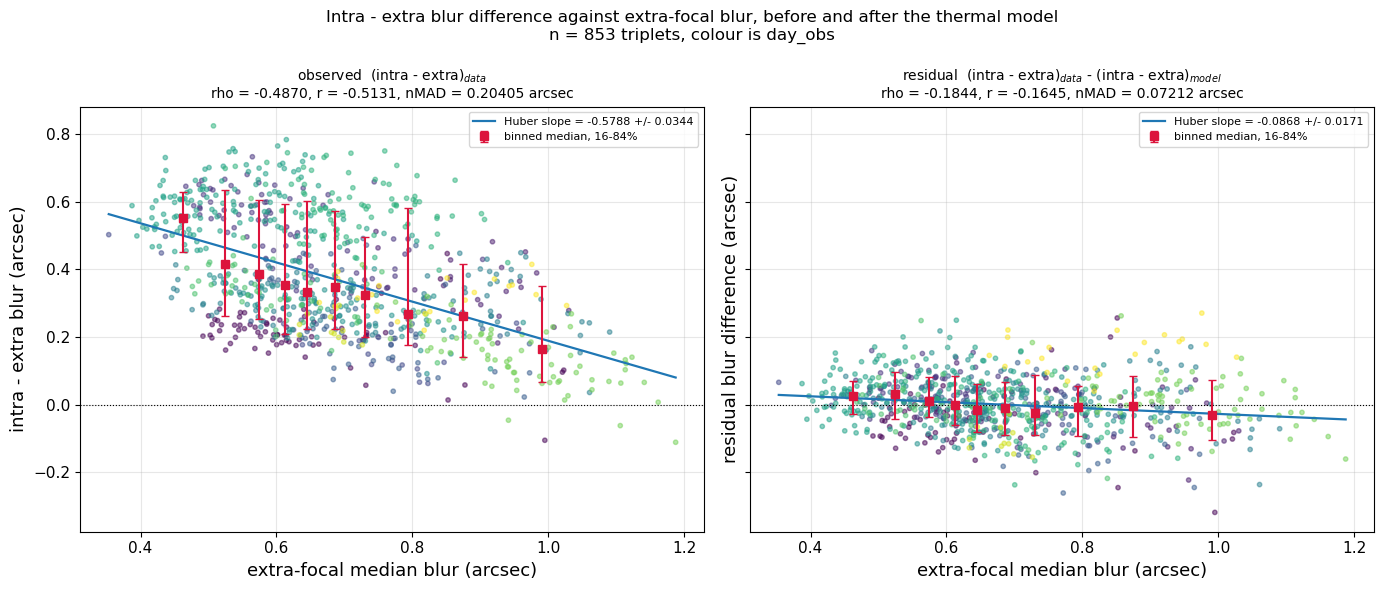

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

grid_x = np.linspace(float(np.min(x_extra)), float(np.max(x_extra)), 200)
panels = (
    (axs[0], y_data, t_data, 'observed  (intra - extra)$_{data}$',
     'intra - extra blur (arcsec)'),
    (axs[1], y_resid, t_resid,
     'residual  (intra - extra)$_{data}$ - (intra - extra)$_{model}$',
     'residual blur difference (arcsec)'),
)
for ax, yv, t, title, ylab in panels:
    ax.scatter(x_extra, yv, s=10, alpha=0.5,
               c=[night_color[n] for n in nights_resid])
    ax.axhline(0.0, color='k', linewidth=0.8, linestyle=':')
    ax.plot(grid_x, t['intercept'] + t['slope'] * grid_x, color='#1f77b4', linewidth=1.6,
            label=f'Huber slope = {t["slope"]:+.4f} +/- {t["slope_err"]:.4f}')
    c_, m_, lo_, hi_ = binned_median(x_extra, yv)
    ax.errorbar(c_, m_, yerr=[m_ - lo_, hi_ - m_], fmt='s', color='crimson',
                markersize=6, capsize=3, linewidth=1.5, label='binned median, 16-84%')
    ax.set_xlabel('extra-focal median blur (arcsec)')
    ax.set_ylabel(ylab)
    ax.set_title(f'{title}\nrho = {t["spearman_rho"]:+.4f}, r = {t["pearson_r"]:+.4f}, '
                 f'nMAD = {t["nmad"]:.5f} arcsec', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle(f'Intra - extra blur difference against extra-focal blur, before and after '
             f'the thermal model\nn = {n_resid} triplets, colour is day_obs', fontsize=12)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUT_DIR / 'blur_diff_resid_vs_extra_blur.pdf')
plt.show()


<a id='summary'></a>
## 9. Summary


In [18]:
print(f'{PARAM_SET}: {n_fit} FAM triplets with a finite blur median on both sides\n')
print(f'median intra-focal blur     = {np.median(bi):.4f} arcsec')
print(f'median extra-focal blur     = {np.median(be):.4f} arcsec')
print(f'median (intra - extra)      = {np.median(bi - be):+.4f} arcsec')
print(f'median (intra / extra)      = {np.median(bi / be):.4f} (dimensionless)')
print(f'fraction with intra > extra = {float(np.mean(bi > be)):.4f} '
      f'(dimensionless, of {n_fit} triplets)\n')
for name in ('constant', 'fractional', 'quadrature'):
    m = models[name]
    print(f'{name:11s}: param = {m["param"]:+.5f} {m["param_units"]:28s} '
          f'resid nMAD = {m["nmad_arcsec"]:.5f} arcsec')
print(f'\nlowest robust residual scatter: {best}')
print(f'slope of (intra - extra) on extra blur = {slope:+.5f} +/- {slope_err:.5f} '
      f'(dimensionless)')

print()
print('Thermal dependence of the blur difference intra - extra (nothing subtracted):')
print(f'  {n_q} triplets, median {np.nanmedian(d["blur_diff_arcsec"]):+.5f} arcsec, '
      f'{n_neg} negative')
print(f'  strongest single quantity: {ranked.iloc[0]["feature"]}')
print(f'    Spearman rho = {ranked.iloc[0]["spearman_rho"]:+.4f} full sample, '
      f'{ranked.iloc[0]["spearman_rho_within_night"]:+.4f} within night (dimensionless)')
print(f'  final model keeps {len(final["columns"])} quantities, n = {final["n"]} '
      f'triplets:')
for j, c in enumerate(final['columns']):
    unit = label_of[c].split('(')[-1].rstrip(')')
    print(f'    {label_of[c]:38s} {final["fit"].params[j + 1]:+10.5f} arcsec per {unit}')
print(f'  robust scatter {nmad(final["y"] - np.median(final["y"])):.5f} -> '
      f'{final["resid_nmad"]:.5f} arcsec; prediction vs observed '
      f'Spearman rho = {final["spearman_rho"]:+.4f}')
print(f'  with each night\'s mean removed: Spearman rho = {rho_wn:+.4f} '
      f'(dimensionless) -- the part that is not night-level covariance')
print()
print('Quantities whose full-sample correlation is mostly night-level covariance '
      '(|rho| > 0.3 but |rho within night| < 0.1):')
for _, row in ranked.iterrows():
    if abs(row['spearman_rho']) > 0.3 and abs(row['spearman_rho_within_night']) < 0.1:
        print(f'  {row["feature"]:38s} rho = {row["spearman_rho"]:+.4f} full sample, '
              f'{row["spearman_rho_within_night"]:+.4f} within night (dimensionless)')

print()
print('Trend against extra-focal blur, before and after removing the thermal model:')
print(f'  observed difference    slope = {t_data["slope"]:+.5f} +/- '
      f'{t_data["slope_err"]:.5f} arcsec per arcsec, rho = '
      f'{t_data["spearman_rho"]:+.4f}, nMAD = {t_data["nmad"]:.5f} arcsec')
print(f'  thermal-model residual slope = {t_resid["slope"]:+.5f} +/- '
      f'{t_resid["slope_err"]:.5f} arcsec per arcsec, rho = '
      f'{t_resid["spearman_rho"]:+.4f}, nMAD = {t_resid["nmad"]:.5f} arcsec')
print(f'  n = {n_resid} triplets (the subset where every chosen thermal column is '
      f'finite)')


danish_1_3_test: 873 FAM triplets with a finite blur median on both sides

median intra-focal blur     = 1.0526 arcsec
median extra-focal blur     = 0.6636 arcsec
median (intra - extra)      = +0.3440 arcsec
median (intra / extra)      = 1.4999 (dimensionless)
fraction with intra > extra = 0.9954 (dimensionless, of 873 triplets)

constant   : param = +0.34395 arcsec                       resid nMAD = 0.20379 arcsec
fractional : param = +1.49989 dimensionless (intra/extra)  resid nMAD = 0.23984 arcsec
quadrature : param = +0.56140 arcsec**2                    resid nMAD = 0.17863 arcsec

lowest robust residual scatter: {'column': 'cam_AverageTemp', 'n': 855, 'median': 0.00041500664010385435, 'nmad': 0.003076444223110941, 'ratio': np.float64(0.0012369603760373105), 'rho': np.float64(-0.18331827533822295)}
slope of (intra - extra) on extra blur = -0.57640 +/- 0.03444 (dimensionless)

Thermal dependence of the blur difference intra - extra (nothing subtracted):
  873 triplets, median +0.34